##**Practical No.8: Part A: Multiple Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [2]:
df=pd.read_csv("medical_insurance (1).csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [4]:
df.shape

(100000, 54)

In [5]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [6]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [7]:
print(df.dtypes)

person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

In [8]:
df.isnull().sum()

,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [9]:

# Display missing values
missing_values = df.isnull().sum()
print("\nMissing values:")
print(missing_values[missing_values > 0])


Missing values:
alcohol_freq    30083
dtype: int64


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Remove duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate records before removal:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()

print("Duplicate records after removal:", df.duplicated().sum())

Duplicate records before removal: 0
Duplicate records after removal: 0


## EDA

In [12]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Variables:")
print(numerical_columns)

print("\nCategorical Variables:")
print(categorical_columns)


Numerical Variables:
['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical Variables:
['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [13]:
print("Numerical Variables:")
print(numerical_columns)

print("\nNumber of Numerical Variables:", len(numerical_columns))

print("\nCategorical Variables:")
print(categorical_columns)

print("\nNumber of Categorical Variables:", len(categorical_columns))

Numerical Variables:
['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Number of Numerical Variables: 44

Categorical Variables:
['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']

Number of Categorical 

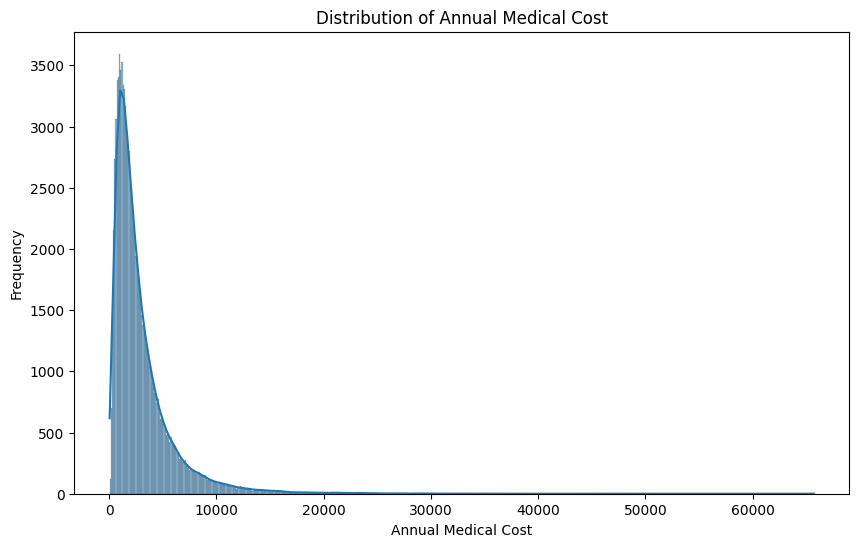

In [14]:
# Distribution of annual medical cost
plt.figure(figsize=(10, 6))
sns.histplot( df["annual_medical_cost"], kde=True)
plt.title("Distribution of Annual Medical Cost")
plt.xlabel("Annual Medical Cost")
plt.ylabel("Frequency")
plt.show()

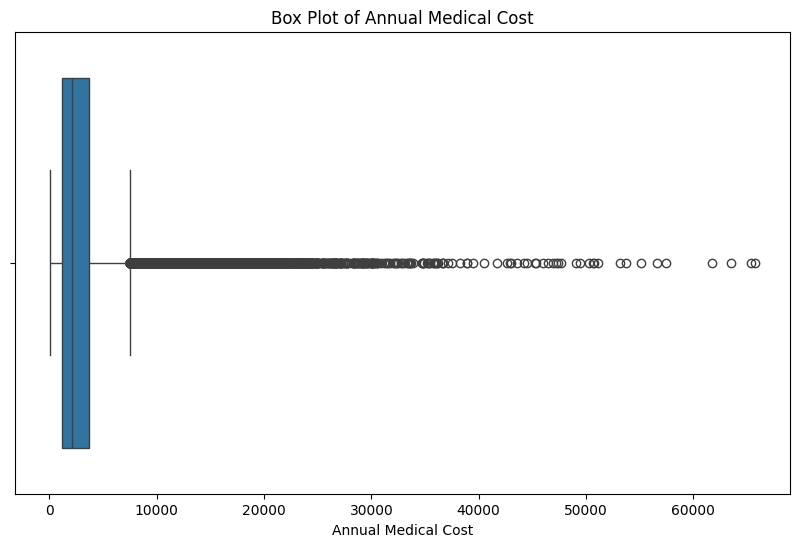

In [15]:
# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["annual_medical_cost"])
plt.title("Box Plot of Annual Medical Cost")
plt.xlabel("Annual Medical Cost")
plt.show()

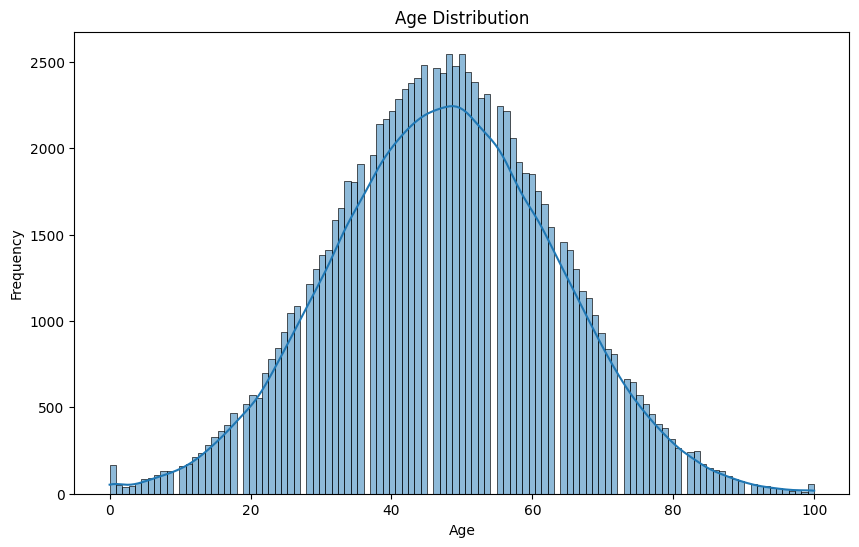

In [16]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["age"],kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

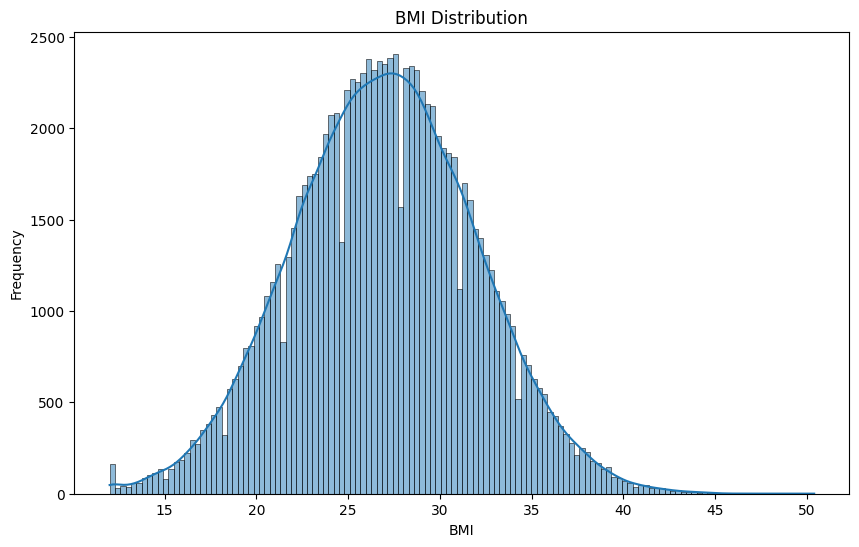

In [17]:
# BMI Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["bmi"],kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

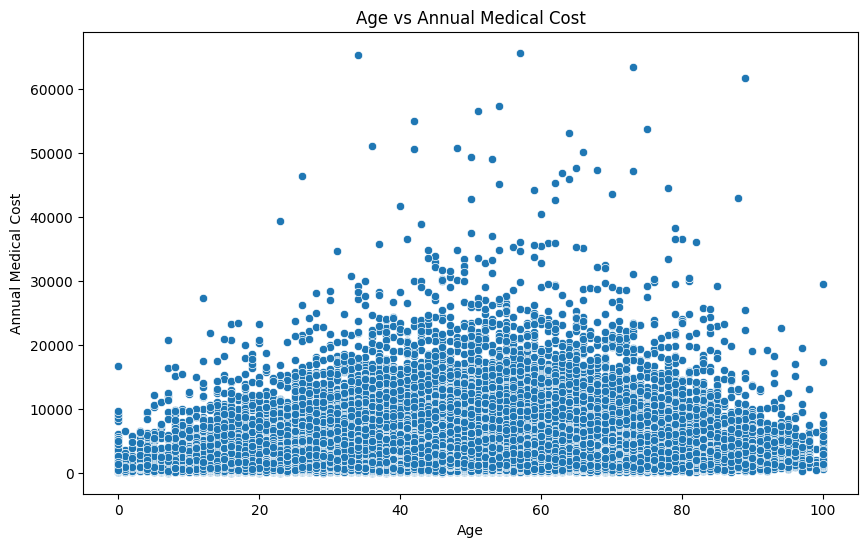

In [18]:
# Scatter Plot
# Age vs Medical Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age",y="annual_medical_cost")
plt.title("Age vs Annual Medical Cost")
plt.xlabel("Age")
plt.ylabel("Annual Medical Cost")
plt.show()

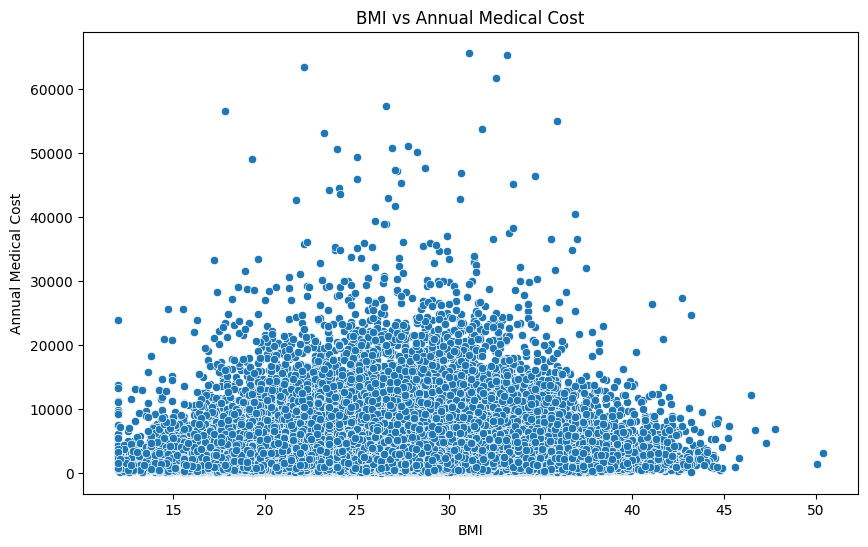

In [19]:
# BMI VS Medical Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="bmi",y="annual_medical_cost")
plt.title("BMI vs Annual Medical Cost")
plt.xlabel("BMI")
plt.ylabel("Annual Medical Cost")
plt.show()

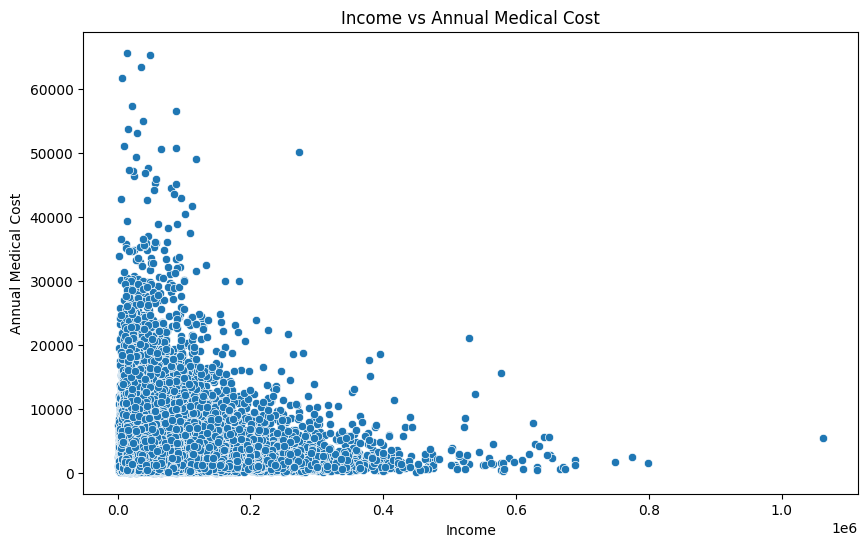

In [20]:
#Income vs Annual Medical Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="income",y="annual_medical_cost")
plt.title("Income vs Annual Medical Cost")
plt.xlabel("Income")
plt.ylabel("Annual Medical Cost")
plt.show()

### 4. Correlation Analysis

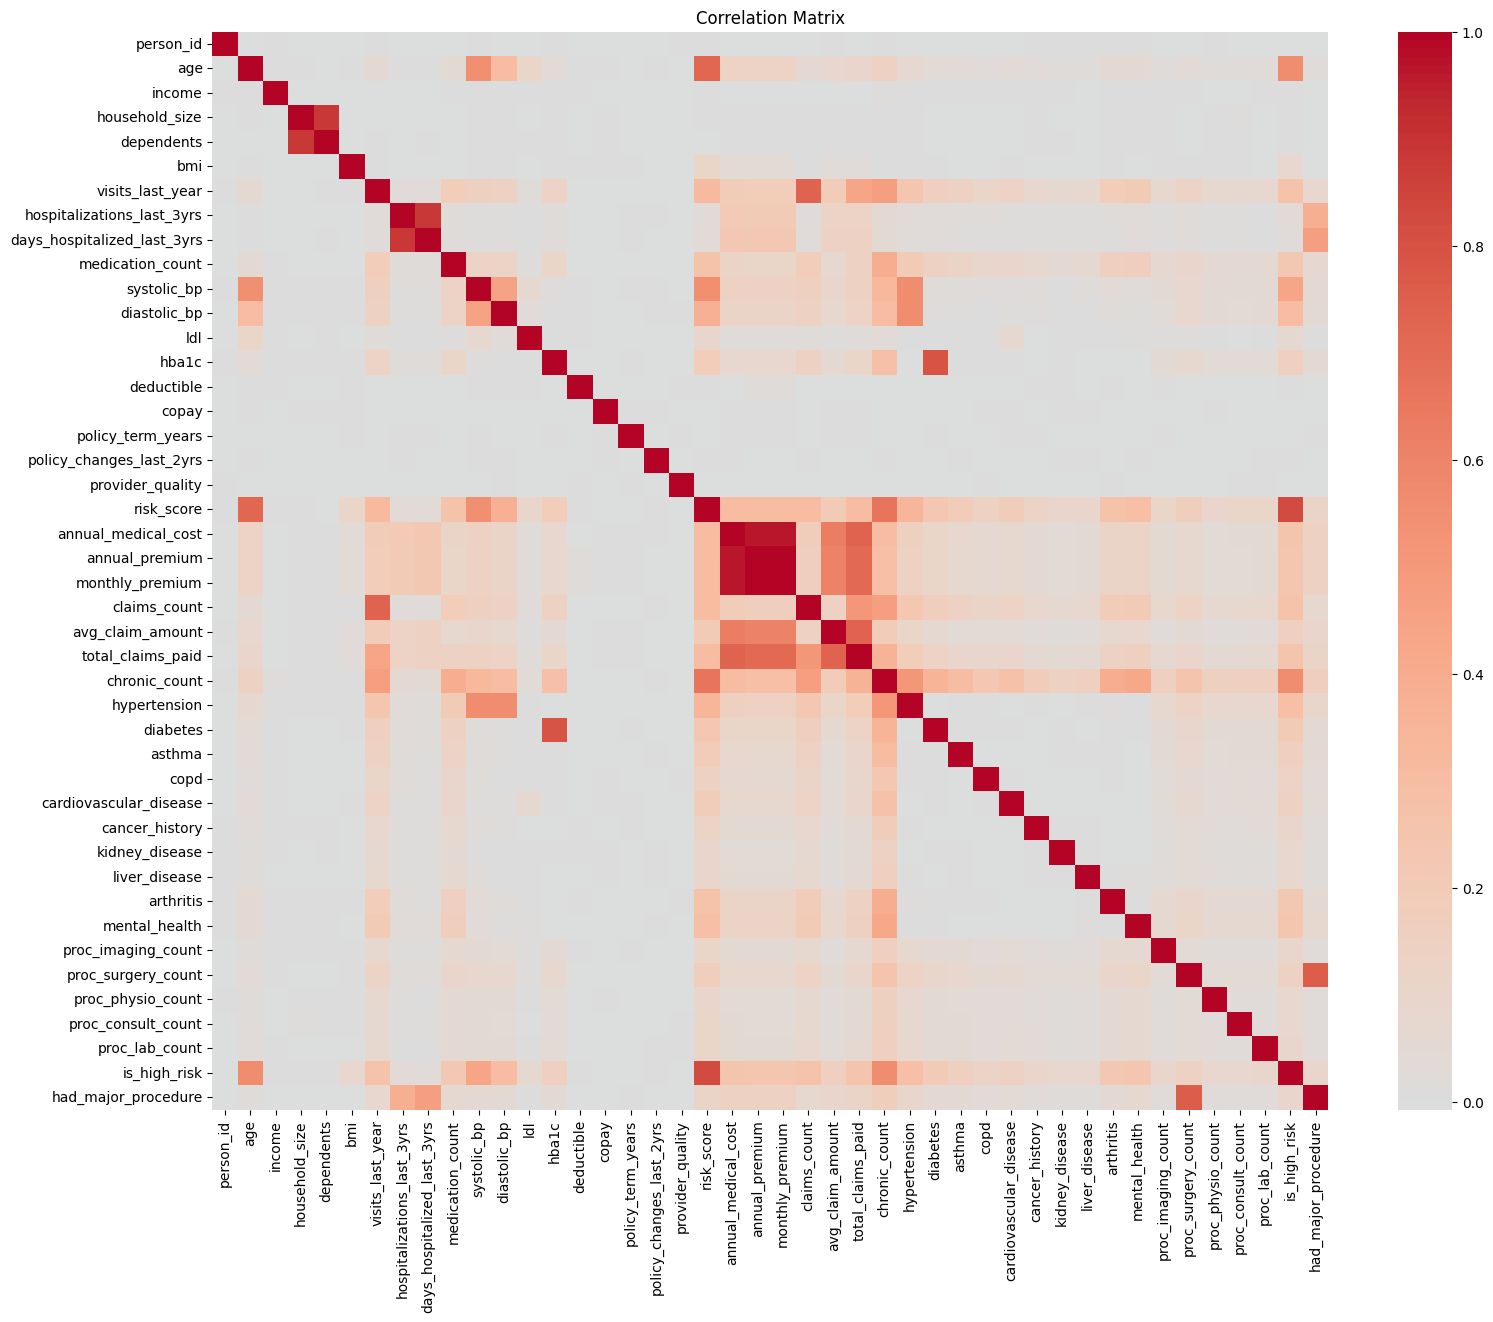

In [21]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

### correlation with target

In [22]:
target_correlation = (
    correlation_matrix["annual_medical_cost"]
    .sort_values(ascending=False)
)

print("Correlation with Annual Medical Cost:")
print(target_correlation)

Correlation with Annual Medical Cost:
annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
diabetes                       0.107373
hba1c                          0.083416
asthma                         0.080830
cardiovascular_disease         0.078515
pr

### 5. Covariance Analysis

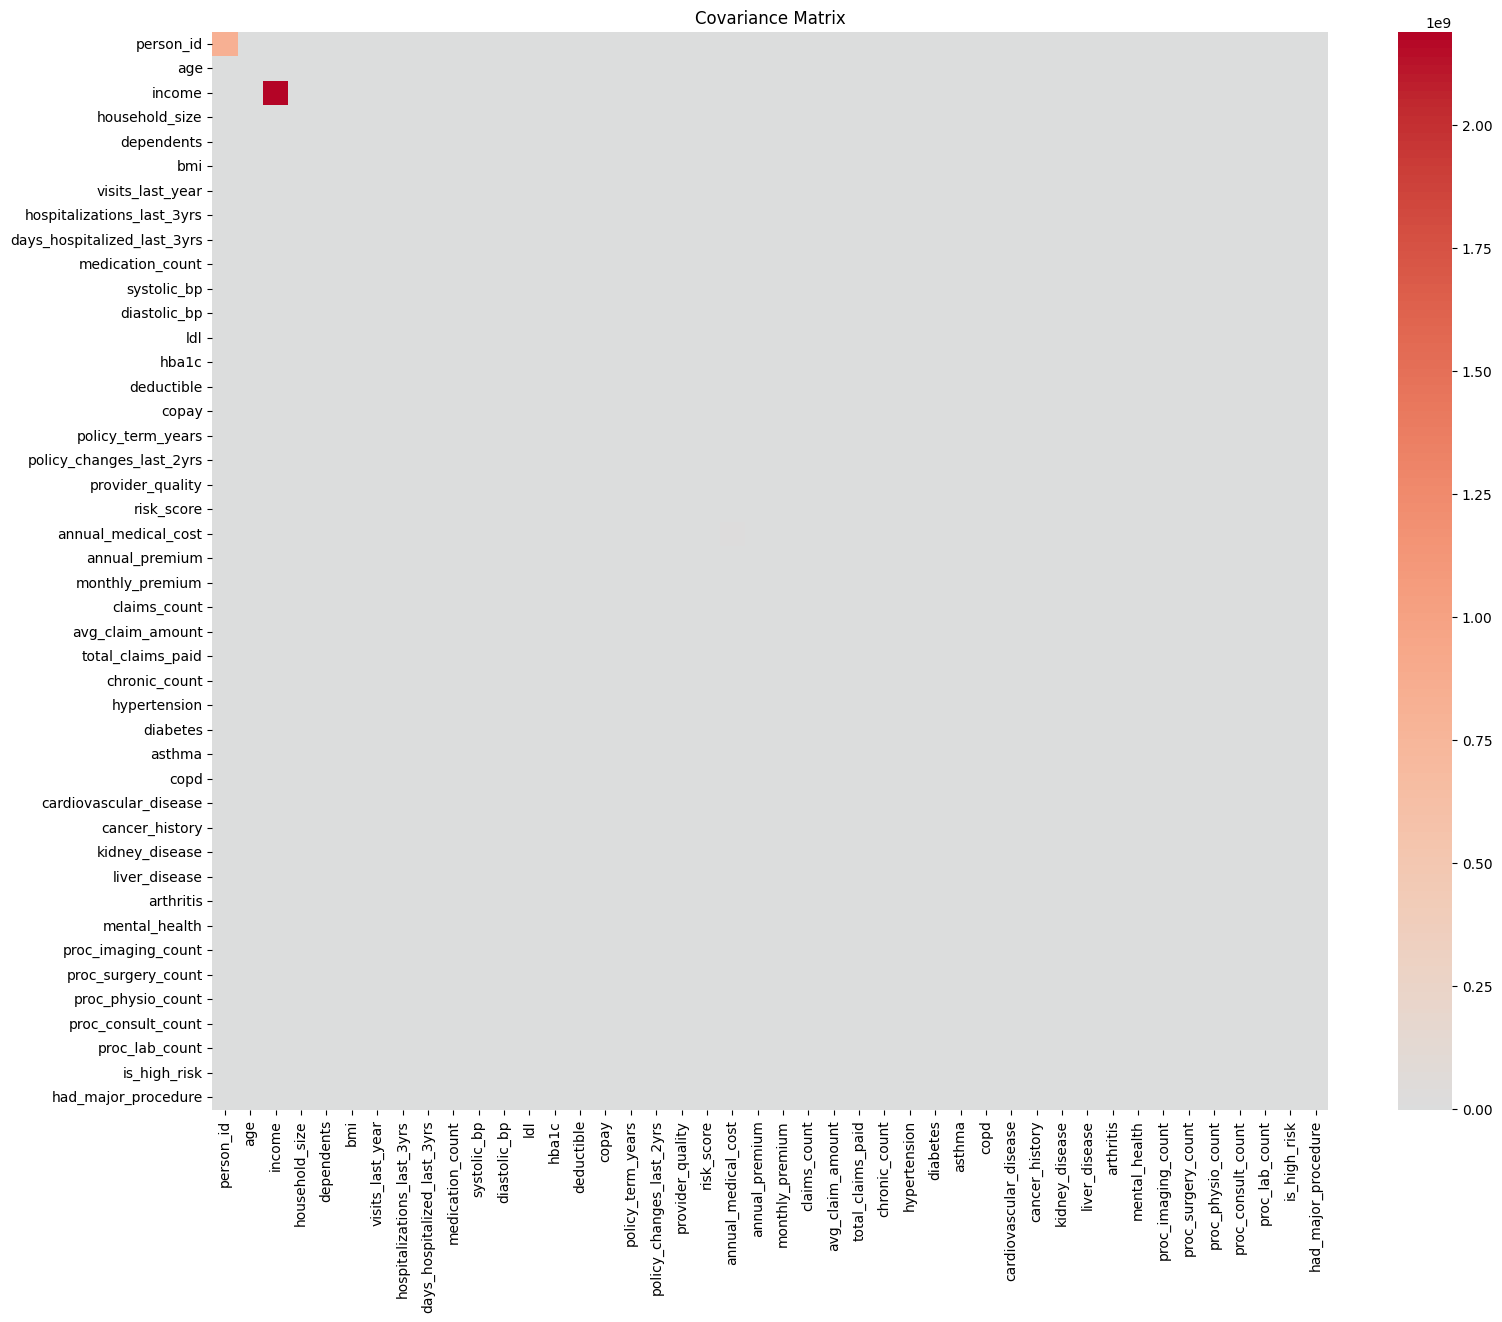

In [23]:
covariance_matrix = df.select_dtypes(include=np.number).cov()
plt.figure(figsize=(18, 14))
sns.heatmap(covariance_matrix, cmap="coolwarm",center=0)
plt.title("Covariance Matrix")
plt.show()

### Correaltion With target Analaysis

In [24]:
target_covariance = (
    covariance_matrix["annual_medical_cost"]
    .sort_values(ascending=False)
)
print("Covariance with Annual Medical Cost:")
print(target_covariance)

Covariance with Annual Medical Cost:
annual_medical_cost            9.781024e+06
total_claims_paid              5.331277e+06
avg_claim_amount               2.123514e+06
annual_premium                 1.206464e+06
monthly_premium                1.005386e+05
systolic_bp                    6.972997e+03
age                            6.558844e+03
diastolic_bp                   3.274984e+03
ldl                            1.931257e+03
claims_count                   1.136848e+03
visits_last_year               1.063196e+03
days_hospitalized_last_3yrs    9.886839e+02
chronic_count                  7.475102e+02
bmi                            6.748125e+02
medication_count               4.291146e+02
is_high_risk                   3.799256e+02
risk_score                     2.398685e+02
hba1c                          2.207040e+02
hospitalizations_last_3yrs     1.989174e+02
hypertension                   1.942768e+02
had_major_procedure            1.740892e+02
mental_health                  1.328290

In [25]:
target = "annual_medical_cost"
# Remove ID and target
X = df.drop(columns=["person_id", target])
y = df[target]

# Identify numerical and categorical variables
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal features:", X.shape[1])

Numerical features:
['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical features:
['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']

Total features: 52


### 6. Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 52)
Testing data: (20000, 52)


In [27]:
from sklearn.impute import SimpleImputer

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing created successfully!")

Preprocessing created successfully!


### 7. Multiple Linear Regression

In [28]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test,linear_pred)
linear_rmse = np.sqrt(
    mean_squared_error( y_test, linear_pred)
)

linear_r2 = r2_score(y_test,linear_pred)
print("Multiple Linear Regression")
print("--------------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

Multiple Linear Regression
--------------------------------
MAE : 319.9110966962151
RMSE: 574.8724622514113
R2  : 0.9664153085493414


8. Ridge Regression

In [29]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_mae = mean_absolute_error(y_test,ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(y_test,ridge_pred)
print("Ridge Regression")
print("Alpha:", 1.0)
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2  :", ridge_r2)

Ridge Regression
Alpha: 1.0
MAE : 319.90473706875724
RMSE: 574.8697933136826
R2  : 0.9664156203932649


## 9. Lasso Regression

In [30]:
lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(
            alpha=0.01,
            max_iter=10000
        ))
    ]
)

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
lasso_mae = mean_absolute_error(y_test,lasso_pred)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

lasso_r2 = r2_score( y_test,lasso_pred)

print("Lasso Regression")
print("Alpha:", 0.01)
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R2  :", lasso_r2)

Lasso Regression
Alpha: 0.01
MAE : 319.8921201981673
RMSE: 574.8659980108727
R2  : 0.9664160638414022


### 10. Decision Tree

In [31]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=15,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train,y_train)
dt_pred = decision_tree_model.predict(X_test)
dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_r2 = r2_score(y_test,dt_pred)

print("Decision Tree Regression")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)

Decision Tree Regression
MAE : 9.701708671069367
RMSE: 138.8374372569191
R2  : 0.9980411033248898


### 11. Random Forest

In [32]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=30,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)
rf_r2 = r2_score(
    y_test, y_pred_rf
)

print("Random Forest Regression")
print("-----------------------------")
print("Number of Trees:", 30)
print("Max Depth:", 10)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Regression
-----------------------------
Number of Trees: 30
Max Depth: 10
MAE: 31.102827725430437
RMSE: 140.11106881032762
R2 Score: 0.9980049984203042


### Compare All Models

In [33]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

### 12. Model Selection

In [34]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:")
print(best_model_name)

print("\nBest R2 Score:")
print(results.iloc[0]["R2 Score"])

print("\nBest MAE:")
print(results.iloc[0]["MAE"])

print("\nBest RMSE:")
print(results.iloc[0]["RMSE"])

Best Model:
Decision Tree

Best R2 Score:
0.9980411033248898

Best MAE:
9.701708671069367

Best RMSE:
138.8374372569191


### Actual vs Predicted Plot

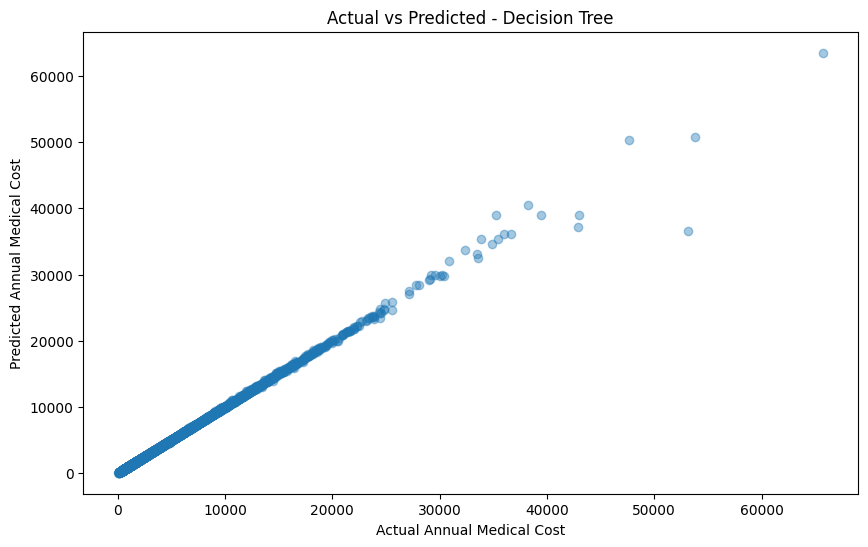

In [36]:
models = {
    "Multiple Linear Regression": (
        linear_model,
        linear_pred
    ),

    "Ridge Regression": (
        ridge_model,
        ridge_pred
    ),

    "Lasso Regression": (
        lasso_model,
        lasso_pred
    ),

    "Decision Tree": (
        decision_tree_model,
        dt_pred
    ),

    "Random Forest": (
        random_forest_model,
        y_pred_rf
    )
}

best_model = models[best_model_name][0]
best_predictions = models[best_model_name][1]

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")

plt.title(
    "Actual vs Predicted - " + best_model_name
)

plt.show()


### 13. Save the Best Model using Joblib

In [37]:
joblib.dump(best_model,"medical_insurance_best_model.pkl")
print("Best model saved successfully!")
print("File:")
print("medical_insurance_best_model.pkl")

Best model saved successfully!
File:
medical_insurance_best_model.pkl


In [39]:
import joblib

joblib.dump(random_forest_model, "best_insurance_model.pkl")

# Save feature names also
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


### 14. Create Prediction Interface

In [40]:
import gradio as gr
import pandas as pd
import joblib

# Load saved model
model = joblib.load(
    "medical_insurance_best_model.pkl"
)

# Input columns
input_columns = X.columns.tolist()

# Create Gradio input components
inputs = []

for column in input_columns:

    if column in categorical_features:

        choices = sorted(
            df[column].dropna().unique().tolist()
        )

        inputs.append(
            gr.Dropdown(
                choices=choices,
                label=column
            )
        )

    else:

        default_value = float(
            df[column].median()
        )

        inputs.append(
            gr.Number(
                value=default_value,
                label=column
            )
        )


def predict_medical_cost(*values):

    input_data = pd.DataFrame(
        [values],
        columns=input_columns
    )

    prediction = model.predict(
        input_data
    )[0]

    return f"Predicted Annual Medical Cost: ₹{prediction:,.2f}"


interface = gr.Interface(
    fn=predict_medical_cost,
    inputs=inputs,
    outputs=gr.Textbox(
        label="Prediction"
    ),
    title="Medical Insurance Cost Prediction",
    description="Enter patient and insurance details to predict annual medical cost."
)

interface.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://17805e94a991d6c389.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
